In [21]:
# ============================================================
# STAGE 1
# PyTorch Face Recognition Training Pipeline
# ============================================================

import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_ROOT = Path(
    r"E:\Pyhton code\Deep Learning\CNN\Face Recognition Model"
)


# ============================================================
# DATASET PATHS
# ============================================================

DATA_ROOT = (
    PROJECT_ROOT
    / "data"
    / "labeled wild face dataset 13000 images"
)


# LFW dataset
DATASET_ROOT = (
    DATA_ROOT
    / "lfw-deepfunneled"
    / "lfw-deepfunneled"
)


# Your face dataset
MY_FACE_DIR = (
    DATA_ROOT
    /"lfw-deepfunneled"
    / "my face"
)


# YuNet model
YUNET_PATH = (
    PROJECT_ROOT
    / "face_detection_yunet_2023mar.onnx"
)


# ============================================================
# CHECK PATHS
# ============================================================

print("=" * 60)
print("PATH CHECK")
print("=" * 60)

print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Data root:",
    DATA_ROOT
)

print(
    "LFW dataset exists:",
    DATASET_ROOT.exists()
)

print(
    "My face folder exists:",
    MY_FACE_DIR.exists()
)

print(
    "YuNet exists:",
    YUNET_PATH.exists()
)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "\nDevice:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PATH CHECK
Project root: E:\Pyhton code\Deep Learning\CNN\Face Recognition Model
Data root: E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\labeled wild face dataset 13000 images
LFW dataset exists: True
My face folder exists: True
YuNet exists: True

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [22]:
# ============================================================
# SELECTED PEOPLE
# ============================================================

selected_people = [

    "George_W_Bush",
    "Colin_Powell",
    "Tony_Blair",
    "Donald_Rumsfeld",
    "Gerhard_Schroeder",
    "Ariel_Sharon",
    "Hugo_Chavez",
    "Junichiro_Koizumi",
    "Jean_Chretien",
    "John_Ashcroft",

    # Our own class
    "My_Face"
]


# ============================================================
# CLASS MAPPING
# ============================================================

class_to_idx = {

    person: idx

    for idx, person
    in enumerate(selected_people)
}


idx_to_class = {

    idx: person

    for person, idx
    in class_to_idx.items()
}


print("Number of classes:", len(selected_people))

print("\nClasses:")

for idx, person in idx_to_class.items():

    print(
        f"{idx}: {person}"
    )

Number of classes: 11

Classes:
0: George_W_Bush
1: Colin_Powell
2: Tony_Blair
3: Donald_Rumsfeld
4: Gerhard_Schroeder
5: Ariel_Sharon
6: Hugo_Chavez
7: Junichiro_Koizumi
8: Jean_Chretien
9: John_Ashcroft
10: My_Face


In [23]:
# ============================================================
# YUNET FACE DETECTOR
# ============================================================

face_detector = cv2.FaceDetectorYN.create(

    str(YUNET_PATH),

    "",

    (320, 320),

    0.80,

    0.3,

    5000
)


print("YuNet face detector loaded successfully!")

YuNet face detector loaded successfully!


In [24]:
# ============================================================
# FACE DETECTION
# ============================================================

def detect_largest_face(image):

    """
    Detect faces and return the largest reliable face.

    Returns:
        face_crop
        bbox
        confidence

    If no reliable face is found:
        returns (None, None, None)
    """

    if image is None:

        return None, None, None


    height, width = image.shape[:2]


    # Tell YuNet the actual image size
    face_detector.setInputSize(

        (width, height)
    )


    _, faces = face_detector.detect(

        image
    )


    if faces is None:

        return None, None, None


    candidates = []


    for face_data in faces:

        x, y, w, h = face_data[:4]

        confidence = float(
            face_data[-1]
        )


        # Detection confidence
        if confidence < 0.80:

            continue


        x1 = max(
            0,
            int(x)
        )

        y1 = max(
            0,
            int(y)
        )

        x2 = min(
            width,
            int(x + w)
        )

        y2 = min(
            height,
            int(y + h)
        )


        if x2 <= x1 or y2 <= y1:

            continue


        area = (
            x2 - x1
        ) * (
            y2 - y1
        )


        candidates.append(

            (
                area,
                confidence,
                (x1, y1, x2, y2)
            )
        )


    if not candidates:

        return None, None, None


    # Choose largest face
    candidates.sort(

        key=lambda x: x[0],

        reverse=True
    )


    _, confidence, bbox = candidates[0]


    x1, y1, x2, y2 = bbox


    face_crop = image[

        y1:y2,

        x1:x2
    ]


    if face_crop.size == 0:

        return None, None, None


    return (

        face_crop,

        bbox,

        confidence
    )


print("Face detection function ready!")

Face detection function ready!


In [25]:
# ============================================================
# IMAGE ENHANCEMENT
# ============================================================

def enhance_face(face):

    """
    Mild image enhancement.

    This is intentionally conservative.
    We don't want to generate artificial-looking faces.
    """

    if face is None or face.size == 0:

        return face


    # --------------------------------------------------------
    # Convert BGR → LAB
    # --------------------------------------------------------

    lab = cv2.cvtColor(

        face,

        cv2.COLOR_BGR2LAB
    )


    l, a, b = cv2.split(lab)


    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(

        clipLimit=2.0,

        tileGridSize=(8, 8)
    )


    l = clahe.apply(l)


    lab = cv2.merge(

        (l, a, b)
    )


    enhanced = cv2.cvtColor(

        lab,

        cv2.COLOR_LAB2BGR
    )


    # --------------------------------------------------------
    # Mild sharpening
    # --------------------------------------------------------

    kernel = np.array(

        [
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ],

        dtype=np.float32
    )


    enhanced = cv2.filter2D(

        enhanced,

        -1,

        kernel
    )


    return enhanced


print("Enhancement function ready!")

Enhancement function ready!


In [26]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

IMAGE_SIZE = 224


# ------------------------------------------------------------
# TRAINING TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(

        brightness=0.20,

        contrast=0.20,

        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ------------------------------------------------------------
# VALIDATION TRANSFORM
# ------------------------------------------------------------

val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


print("Training transform ready.")
print("Validation transform ready.")

Training transform ready.
Validation transform ready.


In [27]:
# ============================================================
# BUILD SAMPLE LIST
# ============================================================

IMAGE_EXTENSIONS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}


samples = []


# ============================================================
# LFW PEOPLE
# ============================================================

for person in selected_people[:-1]:

    person_dir = (
        DATASET_ROOT / person
    )


    if not person_dir.exists():

        print(
            "WARNING: missing:",
            person
        )

        continue


    label = class_to_idx[person]


    for image_path in sorted(

        person_dir.iterdir()
    ):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:

            continue


        samples.append({

            "path": str(image_path),

            "label": label,

            "person": person
        })


# ============================================================
# YOUR FACE
# ============================================================

my_face_label = class_to_idx["My_Face"]


for image_path in sorted(

    MY_FACE_DIR.iterdir()
):

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:

        continue


    samples.append({

        "path": str(image_path),

        "label": my_face_label,

        "person": "My_Face"
    })


print(
    "Total original samples:",
    len(samples)
)


print("\nSamples per class:")

for person in selected_people:

    count = sum(

        sample["person"] == person

        for sample in samples
    )

    print(
        f"{person:25s} → {count}"
    )

Total original samples: 1484

Samples per class:
George_W_Bush             → 530
Colin_Powell              → 236
Tony_Blair                → 144
Donald_Rumsfeld           → 121
Gerhard_Schroeder         → 109
Ariel_Sharon              → 77
Hugo_Chavez               → 71
Junichiro_Koizumi         → 60
Jean_Chretien             → 55
John_Ashcroft             → 53
My_Face                   → 28


In [28]:
# ============================================================
# BUILD SAMPLE LIST
# ============================================================

IMAGE_EXTENSIONS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}


samples = []


# ============================================================
# LFW PEOPLE
# ============================================================

for person in selected_people[:-1]:

    person_dir = (
        DATASET_ROOT / person
    )


    if not person_dir.exists():

        print(
            "WARNING: missing:",
            person
        )

        continue


    label = class_to_idx[person]


    for image_path in sorted(

        person_dir.iterdir()
    ):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:

            continue


        samples.append({

            "path": str(image_path),

            "label": label,

            "person": person
        })


# ============================================================
# YOUR FACE
# ============================================================

my_face_label = class_to_idx["My_Face"]


for image_path in sorted(

    MY_FACE_DIR.iterdir()
):

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:

        continue


    samples.append({

        "path": str(image_path),

        "label": my_face_label,

        "person": "My_Face"
    })


print(
    "Total original samples:",
    len(samples)
)


print("\nSamples per class:")

for person in selected_people:

    count = sum(

        sample["person"] == person

        for sample in samples
    )

    print(
        f"{person:25s} → {count}"
    )

Total original samples: 1484

Samples per class:
George_W_Bush             → 530
Colin_Powell              → 236
Tony_Blair                → 144
Donald_Rumsfeld           → 121
Gerhard_Schroeder         → 109
Ariel_Sharon              → 77
Hugo_Chavez               → 71
Junichiro_Koizumi         → 60
Jean_Chretien             → 55
John_Ashcroft             → 53
My_Face                   → 28


In [29]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

random.seed(42)


train_samples = []

val_samples = []


# ============================================================
# SPLIT EACH PERSON SEPARATELY
# ============================================================

for person in selected_people:

    person_samples = [

        sample

        for sample in samples

        if sample["person"] == person
    ]


    random.shuffle(

        person_samples
    )


    total = len(

        person_samples
    )


    # --------------------------------------------------------
    # Validation size
    # --------------------------------------------------------

    if total <= 5:

        val_count = 1

    else:

        val_count = max(

            2,

            int(total * 0.20)
        )


    # Make sure we don't put everything in validation
    val_count = min(

        val_count,

        total - 1
    )


    val_part = person_samples[

        :val_count
    ]


    train_part = person_samples[

        val_count:
    ]


    train_samples.extend(

        train_part
    )


    val_samples.extend(

        val_part
    )


print(
    "Training samples:",
    len(train_samples)
)


print(
    "Validation samples:",
    len(val_samples)
)


print(
    "Total:",
    len(train_samples) +
    len(val_samples)
)

Training samples: 1191
Validation samples: 293
Total: 1484


In [40]:
# ============================================================
# IMPROVED PYTORCH DATASET
# ============================================================

class FaceRecognitionDataset(Dataset):

    def __init__(
        self,
        samples,
        transform=None,
        cache_images=True
    ):

        self.samples = samples

        self.transform = transform

        self.cache_images = cache_images

        self.cache = {}


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, index):

        sample = self.samples[index]

        image_path = sample["path"]

        label = sample["label"]


        # ----------------------------------------------------
        # CACHE
        # ----------------------------------------------------

        if (
            self.cache_images
            and index in self.cache
        ):

            face = self.cache[index]


        else:

            # ------------------------------------------------
            # Read image
            # ------------------------------------------------

            image = cv2.imread(image_path)


            if image is None:

                raise RuntimeError(
                    f"Could not read image:\n{image_path}"
                )


            # ------------------------------------------------
            # Try YuNet face detection
            # ------------------------------------------------

            face, bbox, confidence = (
                detect_largest_face(image)
            )


            # ------------------------------------------------
            # FALLBACK
            # ------------------------------------------------
            #
            # If YuNet cannot detect a reliable face,
            # use the original image.
            #
            # LFW images are already tightly cropped,
            # so this is much safer than deleting the sample.
            # ------------------------------------------------

            if face is None:

                face = image.copy()

                if not hasattr(
                    self,
                    "_fallback_count"
                ):

                    self._fallback_count = 0

                self._fallback_count += 1


            # ------------------------------------------------
            # Enhancement
            # ------------------------------------------------

            face = enhance_face(face)


            # ------------------------------------------------
            # Cache
            # ------------------------------------------------

            if self.cache_images:

                self.cache[index] = face


        # ----------------------------------------------------
        # Transform
        # ----------------------------------------------------

        if self.transform:

            image_tensor = self.transform(face)

        else:

            face_rgb = cv2.cvtColor(
                face,
                cv2.COLOR_BGR2RGB
            )

            image_tensor = torch.from_numpy(
                face_rgb
            )

            image_tensor = image_tensor.permute(
                2,
                0,
                1
            ).float() / 255.0


        return (
            image_tensor,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )


print(
    "Improved PyTorch Dataset created!"
)

Improved PyTorch Dataset created!


In [41]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = FaceRecognitionDataset(
    train_samples,
    transform=train_transform,
    cache_images=True
)

val_dataset = FaceRecognitionDataset(
    val_samples,
    transform=val_transform,
    cache_images=True
)

print(
    "Training dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

Training dataset: 1191
Validation dataset: 293


In [42]:
# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 32


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print(
    "Training batches:",
    len(train_loader)
)


print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 38
Validation batches: 10


In [43]:
# ============================================================
# TEST TRAINING BATCH
# ============================================================

images, labels = next(

    iter(train_loader)
)


print(
    "Image batch shape:",
    images.shape
)


print(
    "Label batch shape:",
    labels.shape
)


print(
    "Image dtype:",
    images.dtype
)


print(
    "Labels:",
    labels[:10].tolist()
)


print(
    "Minimum:",
    images.min().item()
)


print(
    "Maximum:",
    images.max().item()
)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Labels: [3, 1, 5, 5, 2, 1, 0, 0, 0, 0]
Minimum: -2.1179039478302
Maximum: 2.640000104904175


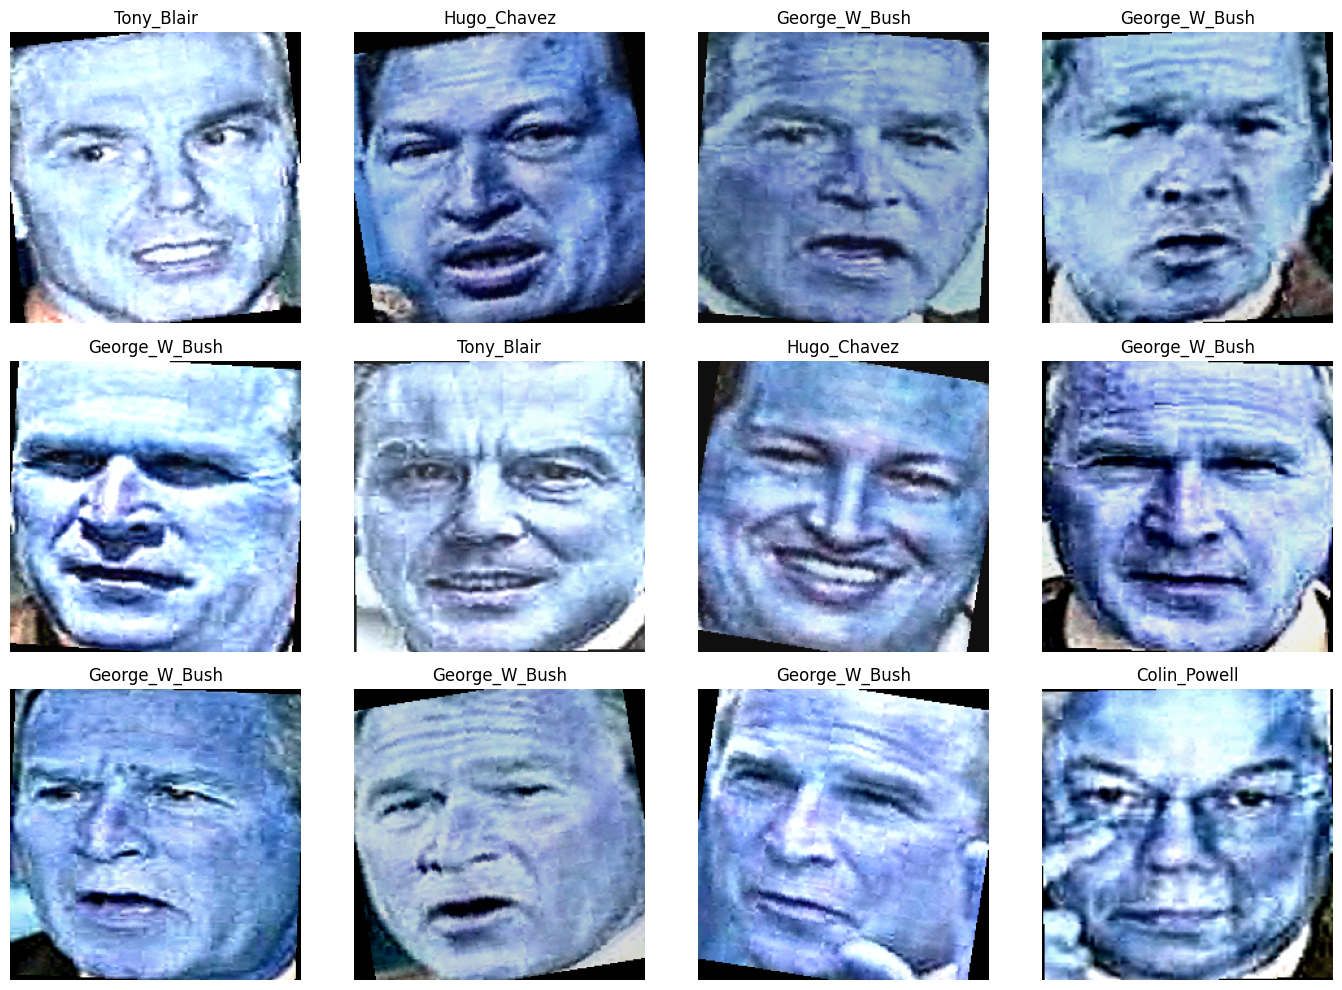

In [44]:
# ============================================================
# VISUALIZE TRAINING DATA
# ============================================================

def denormalize(image_tensor):

    mean = torch.tensor(

        [
            0.485,
            0.456,
            0.406
        ]
    ).view(3, 1, 1)


    std = torch.tensor(

        [
            0.229,
            0.224,
            0.225
        ]
    ).view(3, 1, 1)


    image = (

        image_tensor.cpu()
        * std
        + mean
    )


    image = torch.clamp(

        image,

        0,

        1
    )


    return image.permute(

        1,

        2,

        0
    ).numpy()


# ============================================================
# SHOW 12 TRAINING FACES
# ============================================================

images, labels = next(

    iter(train_loader)
)


plt.figure(

    figsize=(14, 10)
)


for i in range(

    min(12, len(images))
):

    plt.subplot(

        3,

        4,

        i + 1
    )


    image = denormalize(

        images[i]
    )


    plt.imshow(

        image
    )


    person = idx_to_class[

        labels[i].item()
    ]


    plt.title(

        person
    )


    plt.axis("off")


plt.tight_layout()

plt.show()

In [45]:
# ============================================================
# TRAIN / VALIDATION DISTRIBUTION
# ============================================================

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)


for person in selected_people:

    train_count = sum(

        sample["person"] == person

        for sample in train_samples
    )


    val_count = sum(

        sample["person"] == person

        for sample in val_samples
    )


    print(

        f"{person:25s} | "
        f"Train: {train_count:3d} | "
        f"Val: {val_count:2d}"
    )

DATASET SPLIT
George_W_Bush             | Train: 424 | Val: 106
Colin_Powell              | Train: 189 | Val: 47
Tony_Blair                | Train: 116 | Val: 28
Donald_Rumsfeld           | Train:  97 | Val: 24
Gerhard_Schroeder         | Train:  88 | Val: 21
Ariel_Sharon              | Train:  62 | Val: 15
Hugo_Chavez               | Train:  57 | Val: 14
Junichiro_Koizumi         | Train:  48 | Val: 12
Jean_Chretien             | Train:  44 | Val: 11
John_Ashcroft             | Train:  43 | Val: 10
My_Face                   | Train:  23 | Val:  5


In [46]:
# ============================================================
# FINAL PIPELINE CHECK
# ============================================================

print("=" * 60)
print("STAGE 1 PIPELINE CHECK")
print("=" * 60)


print(
    "Classes:",
    len(selected_people)
)


print(
    "Training samples:",
    len(train_dataset)
)


print(
    "Validation samples:",
    len(val_dataset)
)


print(
    "Image size:",
    IMAGE_SIZE
)


print(
    "Batch size:",
    BATCH_SIZE
)


print(
    "Training batches:",
    len(train_loader)
)


print(
    "Validation batches:",
    len(val_loader)
)


print(
    "Device:",
    device
)


print("\nPipeline:")

print(
    "Original Image"
)


print(
    "    ↓ YuNet Face Detection"
)


print(
    "Face Crop"
)


print(
    "    ↓ OpenCV Enhancement"
)


print(
    "Enhanced Face"
)


print(
    "    ↓ Resize 224x224"
)


print(
    "    ↓ Training Augmentation"
)


print(
    "PyTorch Tensor"
)


print(
    "    ↓"
)


print(
    "Ready for ResNet-50 Training"
)


print("\nStage 1 completed successfully!")

STAGE 1 PIPELINE CHECK
Classes: 11
Training samples: 1191
Validation samples: 293
Image size: 224
Batch size: 32
Training batches: 38
Validation batches: 10
Device: cuda

Pipeline:
Original Image
    ↓ YuNet Face Detection
Face Crop
    ↓ OpenCV Enhancement
Enhanced Face
    ↓ Resize 224x224
    ↓ Training Augmentation
PyTorch Tensor
    ↓
Ready for ResNet-50 Training

Stage 1 completed successfully!


In [47]:
# ============================================================
# STAGE 2
# BUILD + TRAIN FACE RECOGNITION MODEL
# ============================================================

import os
import copy
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


In [48]:
# ============================================================
# LOAD PRETRAINED RESNET-50
# ============================================================

weights = ResNet50_Weights.DEFAULT

backbone = resnet50(
    weights=weights
)


print(
    "Pretrained ResNet-50 loaded."
)

Pretrained ResNet-50 loaded.


In [49]:
# ============================================================
# OUR FACE RECOGNITION MODEL
# ============================================================

class FaceRecognitionModel(nn.Module):

    def __init__(
        self,
        num_classes,
        embedding_dim=512
    ):

        super().__init__()


        # ----------------------------------------------------
        # ResNet-50 backbone
        # ----------------------------------------------------

        self.backbone = backbone

        # Remove ImageNet classifier
        self.backbone.fc = nn.Identity()


        # ----------------------------------------------------
        # Our embedding layer
        # ----------------------------------------------------

        self.embedding = nn.Sequential(

            nn.Linear(
                2048,
                embedding_dim
            ),

            nn.BatchNorm1d(
                embedding_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                0.30
            )
        )


        # ----------------------------------------------------
        # Our classifier
        # ----------------------------------------------------

        self.classifier = nn.Linear(

            embedding_dim,

            num_classes
        )


    def forward(
        self,
        x,
        return_embedding=False
    ):

        # ResNet features
        features = self.backbone(x)


        # Our embedding
        embedding = self.embedding(
            features
        )


        # Classification
        logits = self.classifier(
            embedding
        )


        if return_embedding:

            return logits, embedding


        return logits


model = FaceRecognitionModel(

    num_classes=len(selected_people),

    embedding_dim=512
)


model = model.to(device)


print(model)

FaceRecognitionModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [50]:
# ============================================================
# FREEZE RESNET BACKBONE
# ============================================================

for param in model.backbone.parameters():

    param.requires_grad = False


# Our embedding + classifier remain trainable

for param in model.embedding.parameters():

    param.requires_grad = True


for param in model.classifier.parameters():

    param.requires_grad = True


trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


print(
    f"Total parameters: "
    f"{total_params:,}"
)

Trainable parameters: 1,055,755
Total parameters: 24,563,787


In [51]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

train_labels = np.array([

    sample["label"]

    for sample in train_samples
])


class_counts = np.bincount(

    train_labels,

    minlength=len(selected_people)
)


print("Training class counts:\n")


for idx, count in enumerate(
    class_counts
):

    print(
        f"{idx:2d} | "
        f"{selected_people[idx]:25s} | "
        f"{count}"
    )


# ------------------------------------------------------------
# Calculate inverse-frequency weights
# ------------------------------------------------------------

class_weights = (

    len(train_labels)
    /

    (
        len(selected_people)
        *
        np.maximum(
            class_counts,
            1
        )
    )
)


class_weights = torch.tensor(

    class_weights,

    dtype=torch.float32

).to(device)


print("\nClass weights:")

for idx, weight in enumerate(
    class_weights
):

    print(
        f"{selected_people[idx]:25s} → "
        f"{weight.item():.3f}"
    )

Training class counts:

 0 | George_W_Bush             | 424
 1 | Colin_Powell              | 189
 2 | Tony_Blair                | 116
 3 | Donald_Rumsfeld           | 97
 4 | Gerhard_Schroeder         | 88
 5 | Ariel_Sharon              | 62
 6 | Hugo_Chavez               | 57
 7 | Junichiro_Koizumi         | 48
 8 | Jean_Chretien             | 44
 9 | John_Ashcroft             | 43
10 | My_Face                   | 23

Class weights:
George_W_Bush             → 0.255
Colin_Powell              → 0.573
Tony_Blair                → 0.933
Donald_Rumsfeld           → 1.116
Gerhard_Schroeder         → 1.230
Ariel_Sharon              → 1.746
Hugo_Chavez               → 1.900
Junichiro_Koizumi         → 2.256
Jean_Chretien             → 2.461
John_Ashcroft             → 2.518
My_Face                   → 4.708


In [52]:
# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(

    weight=class_weights
)


print(
    "Weighted CrossEntropyLoss created."
)

Weighted CrossEntropyLoss created.


In [53]:
# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-3,

    weight_decay=1e-4
)


# Learning-rate scheduler

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3
)


print(
    "Optimizer:",
    optimizer
)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [54]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()


    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion(

            outputs,

            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Update weights
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += (

            loss.item()
            *
            images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (

            (predictions == labels)
            .sum()
            .item()
        )


        total += labels.size(0)


    epoch_loss = (

        running_loss / total
    )


    epoch_accuracy = (

        correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )

In [55]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate(
    model,
    loader,
    criterion
):

    model.eval()


    running_loss = 0.0

    correct = 0

    total = 0


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(

                outputs,

                labels
            )


            running_loss += (

                loss.item()
                *
                images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            correct += (

                (predictions == labels)
                .sum()
                .item()
            )


            total += labels.size(0)


    loss = (

        running_loss / total
    )


    accuracy = (

        correct / total
    )


    return (
        loss,
        accuracy
    )

In [56]:
# ============================================================
# TRAINING
# ============================================================

NUM_EPOCHS = 15


history = {

    "train_loss": [],
    "train_accuracy": [],

    "val_loss": [],
    "val_accuracy": []
}


best_val_accuracy = 0.0

best_model_state = None


print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)


for epoch in range(
    NUM_EPOCHS
):

    start_time = time.time()


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy = (

        train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy = (

        validate(

            model,

            val_loader,

            criterion
        )
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_accuracy
    )


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(

            model.state_dict()
        )


        best_marker = " ⭐ BEST"

    else:

        best_marker = ""


    elapsed = (
        time.time()
        - start_time
    )


    print(

        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy * 100:.2f}% | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_accuracy * 100:.2f}% | "

        f"Time: {elapsed:.1f}s"

        f"{best_marker}"
    )


print("\nTraining finished!")

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

STARTING TRAINING
Epoch [01/15] | Train Loss: 1.9864 | Train Acc: 26.28% | Val Loss: 1.8582 | Val Acc: 34.81% | Time: 104.4s ⭐ BEST
Epoch [02/15] | Train Loss: 1.4083 | Train Acc: 48.61% | Val Loss: 1.5419 | Val Acc: 47.78% | Time: 16.7s ⭐ BEST
Epoch [03/15] | Train Loss: 1.1002 | Train Acc: 61.13% | Val Loss: 1.4333 | Val Acc: 52.22% | Time: 15.4s ⭐ BEST
Epoch [04/15] | Train Loss: 0.9337 | Train Acc: 65.74% | Val Loss: 1.3850 | Val Acc: 49.49% | Time: 15.2s
Epoch [05/15] | Train Loss: 0.8469 | Train Acc: 65.91% | Val Loss: 1.2839 | Val Acc: 55.97% | Time: 14.4s ⭐ BEST
Epoch [06/15] | Train Loss: 0.8236 | Train Acc: 68.01% | Val Loss: 1.3521 | Val Acc: 55.29% | Time: 14.5s
Epoch [07/15] | Train Loss: 0.7303 | Train Acc: 70.36% | Val Loss: 0.9826 | Val Acc: 70.31% | Time: 14.6s ⭐ BEST
Epoch [08/15] | Train Loss: 0.6964 | Train Acc: 72.71% | Val Loss: 1.0686 | Val Acc: 64.51% | Time: 14.5s
Epoch [09/15] | Train Loss: 0.7061 | Train Acc: 73.89% | Val Loss: 1.2151 | Val Acc: 57.34% | Time

In [57]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )


model.eval()


print(
    "Best model restored."
)


print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

Best model restored.
Best validation accuracy: 70.31%


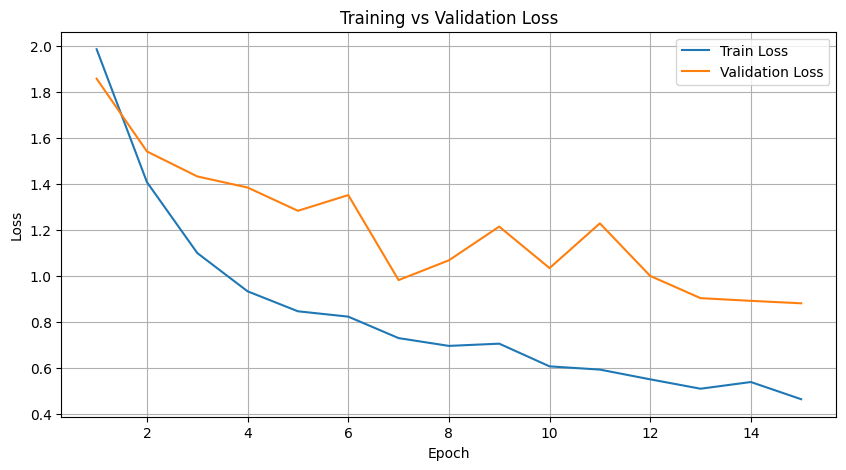

In [58]:
# ============================================================
# TRAINING CURVES
# ============================================================

epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

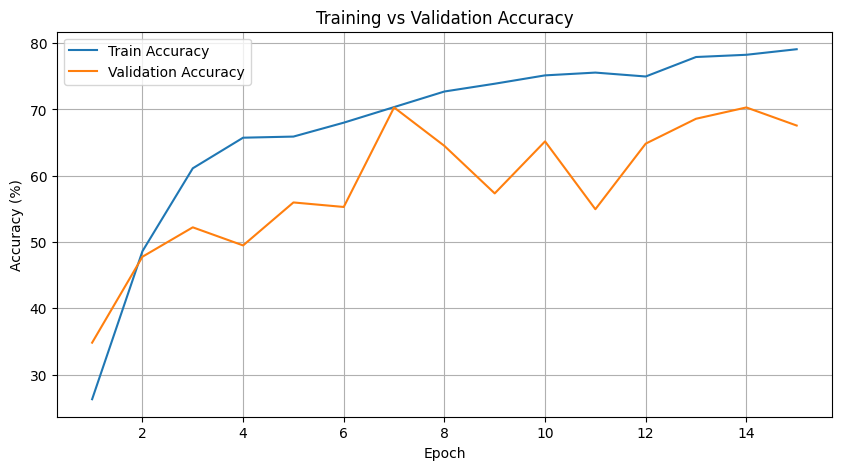

In [59]:
# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs,
    np.array(
        history["train_accuracy"]
    ) * 100,

    label="Train Accuracy"
)

plt.plot(
    epochs,
    np.array(
        history["val_accuracy"]
    ) * 100,

    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

In [60]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

all_predictions = []

all_labels = []


model.eval()


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device
        )


        outputs = model(
            images
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_predictions.extend(

            predictions.cpu().numpy()
        )


        all_labels.extend(

            labels.numpy()
        )


all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)


print(
    "Predictions generated!"
)


print(
    "Number of validation samples:",
    len(all_labels)
)

Predictions generated!
Number of validation samples: 293


In [61]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        all_labels,

        all_predictions,

        labels=np.arange(
            len(selected_people)
        ),

        target_names=selected_people,

        zero_division=0
    )
)

                   precision    recall  f1-score   support

    George_W_Bush       0.85      0.72      0.78       106
     Colin_Powell       0.65      0.87      0.75        47
       Tony_Blair       0.71      0.54      0.61        28
  Donald_Rumsfeld       0.68      0.62      0.65        24
Gerhard_Schroeder       0.59      0.62      0.60        21
     Ariel_Sharon       0.76      0.87      0.81        15
      Hugo_Chavez       0.75      0.43      0.55        14
Junichiro_Koizumi       0.36      0.83      0.50        12
    Jean_Chretien       0.58      0.64      0.61        11
    John_Ashcroft       0.83      0.50      0.62        10
          My_Face       1.00      1.00      1.00         5

         accuracy                           0.70       293
        macro avg       0.71      0.69      0.68       293
     weighted avg       0.74      0.70      0.71       293



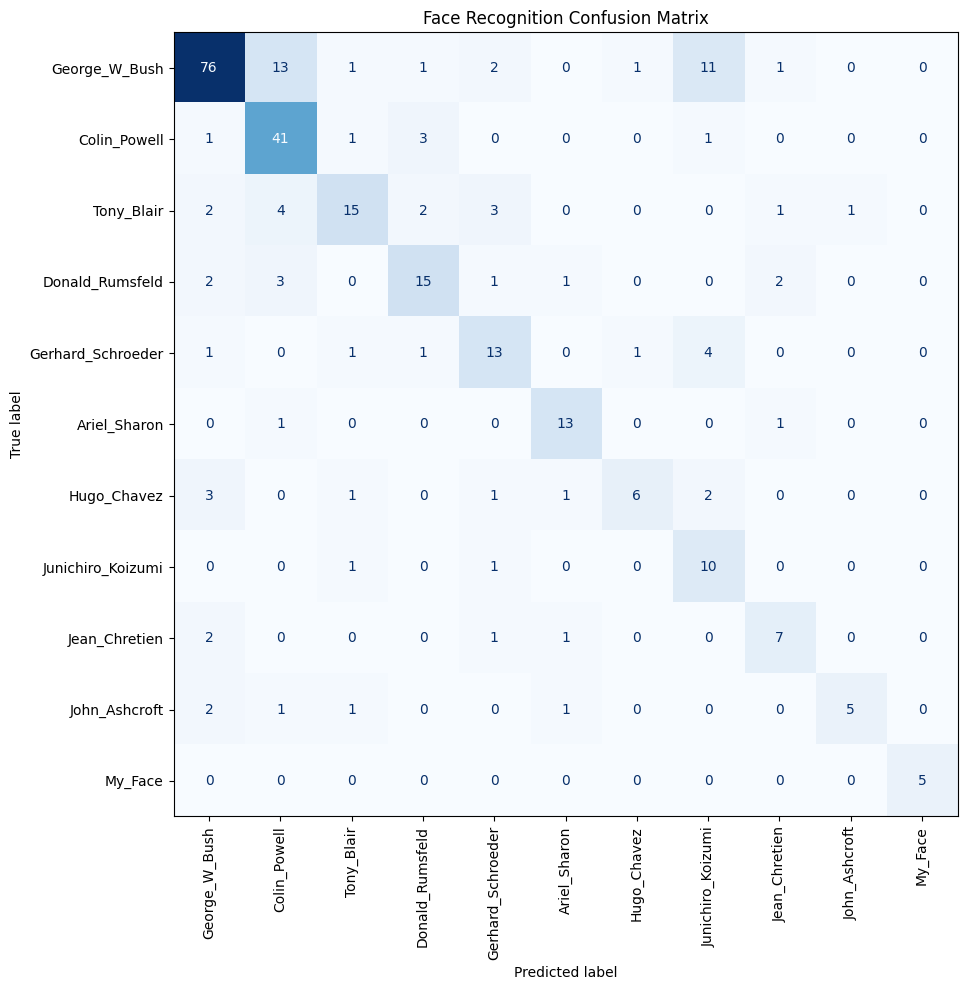

In [62]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    all_labels,

    all_predictions,

    labels=np.arange(
        len(selected_people)
    )
)


fig, ax = plt.subplots(

    figsize=(12, 10)
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=selected_people
)


disp.plot(

    ax=ax,

    xticks_rotation=90,

    cmap="Blues",

    colorbar=False
)


plt.title(
    "Face Recognition Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [63]:
# ============================================================
# SAVE MODEL
# ============================================================

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

MODEL_DIR.mkdir(
    exist_ok=True
)


MODEL_PATH = (
    MODEL_DIR
    / "face_recognition_resnet50.pth"
)


checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "class_to_idx":
        class_to_idx,

    "idx_to_class":
        idx_to_class,

    "selected_people":
        selected_people,

    "embedding_dim":
        512,

    "image_size":
        IMAGE_SIZE,

    "best_val_accuracy":
        best_val_accuracy
}


torch.save(

    checkpoint,

    MODEL_PATH
)


print(
    "Model saved successfully!"
)


print(
    "Path:",
    MODEL_PATH
)


print(
    "File size:",
    f"{MODEL_PATH.stat().st_size / (1024**2):.2f} MB"
)

Model saved successfully!
Path: E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models\face_recognition_resnet50.pth
File size: 94.02 MB


In [64]:
# ============================================================
# TEST EMBEDDING EXTRACTION
# ============================================================

model.eval()


images, labels = next(

    iter(val_loader)
)


images = images.to(
    device
)


with torch.no_grad():

    logits, embeddings = model(

        images,

        return_embedding=True
    )


print(
    "Input shape:",
    images.shape
)


print(
    "Embedding shape:",
    embeddings.shape
)


print(
    "Logits shape:",
    logits.shape
)

Input shape: torch.Size([32, 3, 224, 224])
Embedding shape: torch.Size([32, 512])
Logits shape: torch.Size([32, 11])


In [65]:
# ============================================================
# STAGE 2 CHECK
# ============================================================

print("=" * 70)
print("STAGE 2 COMPLETE")
print("=" * 70)

print(
    "Model: ResNet-50 + custom embedding + classifier"
)

print(
    "Embedding dimension: 512"
)

print(
    "Number of classes:",
    len(selected_people)
)

print(
    "Best validation accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Model path:",
    MODEL_PATH
)

print(
    "\nArchitecture:"
)

print(
    "Face"
)

print(
    " ↓"
)

print(
    "YuNet detection"
)

print(
    " ↓"
)

print(
    "OpenCV enhancement"
)

print(
    " ↓"
)

print(
    "224 × 224"
)

print(
    " ↓"
)

print(
    "ResNet-50"
)

print(
    " ↓"
)

print(
    "512-D learned embedding"
)

print(
    " ↓"
)

print(
    "11-class classifier"
)

print(
    "\nReady for Stage 3!"
)

STAGE 2 COMPLETE
Model: ResNet-50 + custom embedding + classifier
Embedding dimension: 512
Number of classes: 11
Best validation accuracy: 70.31%
Model path: E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models\face_recognition_resnet50.pth

Architecture:
Face
 ↓
YuNet detection
 ↓
OpenCV enhancement
 ↓
224 × 224
 ↓
ResNet-50
 ↓
512-D learned embedding
 ↓
11-class classifier

Ready for Stage 3!


In [1]:
# ============================================================
# STAGE 3
# PyTorch Face Recognition Inference
# ============================================================

import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights


# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_ROOT = Path(
    r"E:\Pyhton code\Deep Learning\CNN\Face Recognition Model"
)

DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "labeled wild face dataset 13000 images"
)

MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset:")
print(DATASET_ROOT)

print("\nModel directory:")
print(MODEL_DIR)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Project root:
E:\Pyhton code\Deep Learning\CNN\Face Recognition Model

Dataset:
E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\labeled wild face dataset 13000 images

Model directory:
E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [2]:
# ============================================================
# FIND TRAINED MODEL FILES
# ============================================================

print("Files inside models folder:\n")

for file in MODEL_DIR.iterdir():

    print(
        file.name,
        "->",
        file.stat().st_size,
        "bytes"
    )

Files inside models folder:

face_recognition_resnet50.pth -> 98590491 bytes


In [9]:
# ============================================================
# DIAGNOSTIC - INSPECT SAVED PYTORCH CHECKPOINT
# ============================================================

from pathlib import Path
import torch


MODEL_PATH = (
    Path.cwd()
    / "models"
    / "face_recognition_resnet50.pth"
)

print("=" * 60)
print("CHECKPOINT DIAGNOSTIC")
print("=" * 60)

print("\nPath:")
print(MODEL_PATH)

print("\nExists:")
print(MODEL_PATH.exists())

print("\nSize:")
print(
    MODEL_PATH.stat().st_size / (1024 * 1024),
    "MB"
)


# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)


print("\nCheckpoint type:")
print(type(checkpoint))


# ------------------------------------------------------------
# Inspect dictionary
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    print("\nDictionary keys:")

    for key in checkpoint.keys():

        print(
            f"  {key}: "
            f"{type(checkpoint[key])}"
        )


# ------------------------------------------------------------
# Inspect state dictionary
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        state_dict = checkpoint[
            "model_state_dict"
        ]

        print(
            "\nUsing: model_state_dict"
        )

    elif "state_dict" in checkpoint:

        state_dict = checkpoint[
            "state_dict"
        ]

        print(
            "\nUsing: state_dict"
        )

    else:

        state_dict = checkpoint

        print(
            "\nUsing checkpoint itself"
        )

else:

    state_dict = checkpoint


# ------------------------------------------------------------
# Show first 20 parameter names
# ------------------------------------------------------------

if isinstance(state_dict, dict):

    print(
        "\nFirst 20 parameter names:"
    )

    for i, key in enumerate(
        state_dict.keys()
    ):

        print(
            f"{i:02d}: {key}"
        )

        if i >= 19:
            break


# ------------------------------------------------------------
# Check important layers
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IMPORTANT LAYER CHECK")
print("=" * 60)

keys = list(
    state_dict.keys()
) if isinstance(
    state_dict,
    dict
) else []


checks = [
    "conv1.weight",
    "layer1.0.conv1.weight",
    "layer4.2.conv3.weight",
    "fc.weight",
    "fc.bias"
]


for key in checks:

    print(
        f"{key:<35} : "
        f"{key in keys}"
    )


print("\nDiagnostic complete.")

CHECKPOINT DIAGNOSTIC

Path:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models\face_recognition_resnet50.pth

Exists:
True

Size:
94.02321910858154 MB

Checkpoint type:
<class 'dict'>

Dictionary keys:
  model_state_dict: <class 'collections.OrderedDict'>
  class_to_idx: <class 'dict'>
  idx_to_class: <class 'dict'>
  selected_people: <class 'list'>
  embedding_dim: <class 'int'>
  image_size: <class 'int'>
  best_val_accuracy: <class 'float'>

Using: model_state_dict

First 20 parameter names:
00: backbone.conv1.weight
01: backbone.bn1.weight
02: backbone.bn1.bias
03: backbone.bn1.running_mean
04: backbone.bn1.running_var
05: backbone.bn1.num_batches_tracked
06: backbone.layer1.0.conv1.weight
07: backbone.layer1.0.bn1.weight
08: backbone.layer1.0.bn1.bias
09: backbone.layer1.0.bn1.running_mean
10: backbone.layer1.0.bn1.running_var
11: backbone.layer1.0.bn1.num_batches_tracked
12: backbone.layer1.0.conv2.weight
13: backbone.layer1.0.bn2.weight
14: backbone.layer1.0.bn2.bia

In [11]:
# ============================================================
# STAGE 3 - LOAD OUR TRAINED FACE RECOGNITION MODEL
# ============================================================

from pathlib import Path

import torch
import torch.nn as nn

from torchvision.models import resnet50


# ============================================================
# 1. MODEL PATH
# ============================================================

PROJECT_ROOT = Path.cwd()

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "face_recognition_resnet50.pth"
)


print("=" * 60)
print("LOADING TRAINED FACE RECOGNITION MODEL")
print("=" * 60)

print("\nModel:")
print(MODEL_PATH)

print("\nExists:")
print(MODEL_PATH.exists())


# ============================================================
# 2. LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

print("\n✓ Checkpoint loaded")


# ============================================================
# 3. READ TRAINING METADATA
# ============================================================

selected_people = checkpoint[
    "selected_people"
]

class_to_idx = checkpoint[
    "class_to_idx"
]

idx_to_class = checkpoint[
    "idx_to_class"
]

embedding_dim = checkpoint[
    "embedding_dim"
]

image_size = checkpoint[
    "image_size"
]

best_val_accuracy = checkpoint[
    "best_val_accuracy"
]


NUM_CLASSES = len(
    selected_people
)


print("\nNumber of classes:")
print(NUM_CLASSES)

print("\nEmbedding dimension:")
print(embedding_dim)

print("\nTraining image size:")
print(image_size)

print("\nBest validation accuracy:")
print(
    f"{best_val_accuracy * 100:.2f}%"
)


print("\nClasses:")

for idx in range(NUM_CLASSES):

    print(
        f"{idx}: {idx_to_class[idx]}"
    )


# ============================================================
# 4. CREATE RESNET-50 BACKBONE
# ============================================================

print(
    "\nCreating ResNet-50..."
)

backbone = resnet50(
    weights=None
)

# Remove ImageNet classifier

backbone.fc = nn.Identity()


# ============================================================
# 5. CREATE 512-D EMBEDDING HEAD
# ============================================================

embedding = nn.Sequential(

    nn.Linear(
        2048,
        512
    ),

    nn.BatchNorm1d(
        512
    )

)


# ============================================================
# 6. CREATE 11-CLASS CLASSIFIER
# ============================================================

classifier = nn.Linear(
    512,
    NUM_CLASSES
)


# ============================================================
# 7. CREATE COMPLETE MODEL
# ============================================================

class FaceRecognitionModel(
    nn.Module
):

    def __init__(
        self,
        backbone,
        embedding,
        classifier
    ):

        super().__init__()

        self.backbone = backbone

        self.embedding = embedding

        self.classifier = classifier


    def forward(
        self,
        x
    ):

        # ResNet-50
        features = self.backbone(x)

        # 2048 → 512
        embedding = self.embedding(
            features
        )

        # 512 → 11
        output = self.classifier(
            embedding
        )

        return output


model = FaceRecognitionModel(
    backbone=backbone,
    embedding=embedding,
    classifier=classifier
)


# ============================================================
# 8. LOAD TRAINED WEIGHTS
# ============================================================

print(
    "\nLoading trained weights..."
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

print(
    "✓ Trained weights loaded successfully!"
)


# ============================================================
# 9. MOVE MODEL TO DEVICE
# ============================================================

model = model.to(
    device
)

model.eval()


# ============================================================
# 10. TEST FORWARD PASS
# ============================================================

print(
    "\nTesting complete model..."
)

dummy_input = torch.randn(
    1,
    3,
    image_size,
    image_size
).to(device)


with torch.no_grad():

    output = model(
        dummy_input
    )


print(
    "Classification output shape:",
    tuple(output.shape)
)


# ============================================================
# 11. TEST EMBEDDING
# ============================================================

print(
    "\nTesting face embedding..."
)

with torch.no_grad():

    features = model.backbone(
        dummy_input
    )

    embedding_output = model.embedding(
        features
    )


print(
    "Embedding shape:",
    tuple(
        embedding_output.shape
    )
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("MODEL READY")
print("=" * 60)

print(
    "Backbone: ResNet-50"
)

print(
    "ResNet features: 2048"
)

print(
    "Face embedding: 512"
)

print(
    "Classes:",
    NUM_CLASSES
)

print(
    "Classifier output:",
    NUM_CLASSES
)

print(
    "Device:",
    device
)

print(
    "\n✓ Stage 2 model reconstructed exactly."
)

print(
    "✓ Trained weights loaded."
)

print(
    "✓ 512-D face embedding available."
)

print(
    "✓ Model ready for face recognition."
)

print("=" * 60)

LOADING TRAINED FACE RECOGNITION MODEL

Model:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models\face_recognition_resnet50.pth

Exists:
True

✓ Checkpoint loaded

Number of classes:
11

Embedding dimension:
512

Training image size:
224

Best validation accuracy:
70.31%

Classes:
0: George_W_Bush
1: Colin_Powell
2: Tony_Blair
3: Donald_Rumsfeld
4: Gerhard_Schroeder
5: Ariel_Sharon
6: Hugo_Chavez
7: Junichiro_Koizumi
8: Jean_Chretien
9: John_Ashcroft
10: My_Face

Creating ResNet-50...

Loading trained weights...
✓ Trained weights loaded successfully!

Testing complete model...
Classification output shape: (1, 11)

Testing face embedding...
Embedding shape: (1, 512)

MODEL READY
Backbone: ResNet-50
ResNet features: 2048
Face embedding: 512
Classes: 11
Classifier output: 11
Device: cuda

✓ Stage 2 model reconstructed exactly.
✓ Trained weights loaded.
✓ 512-D face embedding available.
✓ Model ready for face recognition.


In [12]:
# ============================================================
# MODEL FILE
# ============================================================

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "face_recognition_resnet50.pth"
)

print("Model path:")
print(MODEL_PATH)

print(
    "\nModel exists:",
    MODEL_PATH.exists()
)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"\nModel not found:\n{MODEL_PATH}\n\n"
        "Change MODEL_PATH to the .pth/.pt file "
        "created during Stage 2."
    )

Model path:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\models\face_recognition_resnet50.pth

Model exists: True


In [13]:
# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "George_W_Bush",
    "Colin_Powell",
    "Tony_Blair",
    "Donald_Rumsfeld",
    "Gerhard_Schroeder",
    "Ariel_Sharon",
    "Hugo_Chavez",
    "Junichiro_Koizumi",
    "Jean_Chretien",
    "John_Ashcroft",
    "My_Face"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)

print("\nClasses:")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i}: {name}"
    )

Number of classes: 11

Classes:
0: George_W_Bush
1: Colin_Powell
2: Tony_Blair
3: Donald_Rumsfeld
4: Gerhard_Schroeder
5: Ariel_Sharon
6: Hugo_Chavez
7: Junichiro_Koizumi
8: Jean_Chretien
9: John_Ashcroft
10: My_Face


In [14]:
# ============================================================
# BUILD RESNET-50 MODEL
# ============================================================

print("Building ResNet-50...")

weights = ResNet50_Weights.DEFAULT

model = resnet50(
    weights=None
)

# ResNet-50 produces 2048 features
num_features = model.fc.in_features

print(
    "ResNet feature size:",
    num_features
)


# ============================================================
# CLASSIFICATION HEAD
# ============================================================

model.fc = nn.Sequential(

    nn.Dropout(
        p=0.3
    ),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )
)


model = model.to(device)

print(
    "\nModel architecture created."
)

Building ResNet-50...
ResNet feature size: 2048

Model architecture created.


In [16]:
# ============================================================
# INFERENCE TRANSFORMATION
# ============================================================

inference_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


print(
    "Inference preprocessing ready."
)

print(
    "Input size: 224 x 224"
)

print(
    "Normalization: ImageNet"
)

Inference preprocessing ready.
Input size: 224 x 224
Normalization: ImageNet


In [17]:
# ============================================================
# YUNET FACE DETECTOR
# ============================================================

YUNET_PATH = (
    PROJECT_ROOT
    / "face_detection_yunet_2023mar.onnx"
)

print(
    "YuNet path:",
    YUNET_PATH
)

if not YUNET_PATH.exists():

    raise FileNotFoundError(
        f"\nYuNet model not found:\n{YUNET_PATH}"
    )


# ============================================================
# CREATE DETECTOR
# ============================================================

detector = cv2.FaceDetectorYN.create(

    str(YUNET_PATH),

    "",

    (320, 320),

    0.6,

    0.3,

    5000
)


print(
    "\nYuNet detector loaded successfully!"
)

YuNet path: e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\face_detection_yunet_2023mar.onnx

YuNet detector loaded successfully!


In [18]:
# ============================================================
# DETECT FACE
# ============================================================

def detect_largest_face(image_bgr):
    """
    Detect faces using YuNet.

    Returns:
        face_crop
        bounding_box
        confidence
    """

    if image_bgr is None:
        return None, None, 0.0


    height, width = image_bgr.shape[:2]


    # --------------------------------------------------------
    # Tell YuNet current image size
    # --------------------------------------------------------

    detector.setInputSize(
        (width, height)
    )


    # --------------------------------------------------------
    # Detect
    # --------------------------------------------------------

    _, detections = detector.detect(
        image_bgr
    )


    if detections is None:
        return None, None, 0.0


    candidates = []


    # --------------------------------------------------------
    # Process detections
    # --------------------------------------------------------

    for detection in detections:

        x, y, w, h = (
            detection[:4]
            .astype(int)
        )

        confidence = float(
            detection[-1]
        )


        # Ignore weak detections
        if confidence < 0.70:
            continue


        # Clamp coordinates
        x1 = max(0, x)
        y1 = max(0, y)

        x2 = min(
            width,
            x + w
        )

        y2 = min(
            height,
            y + h
        )


        if x2 <= x1 or y2 <= y1:
            continue


        face_width = x2 - x1
        face_height = y2 - y1

        area = (
            face_width *
            face_height
        )


        candidates.append(
            (
                area,
                confidence,
                (x1, y1, x2, y2)
            )
        )


    if not candidates:

        return None, None, 0.0


    # --------------------------------------------------------
    # Choose largest reliable face
    # --------------------------------------------------------

    candidates.sort(
        key=lambda item: item[0],
        reverse=True
    )


    area, confidence, bbox = (
        candidates[0]
    )


    x1, y1, x2, y2 = bbox


    face_crop = image_bgr[
        y1:y2,
        x1:x2
    ]


    if face_crop.size == 0:

        return None, None, 0.0


    return (
        face_crop,
        bbox,
        confidence
    )


print(
    "Face detection function ready."
)

Face detection function ready.


In [19]:
# ============================================================
# OPENCV FACE ENHANCEMENT
# ============================================================

def enhance_face(face_bgr):
    """
    Level-1 OpenCV enhancement.

    Does:
    - CLAHE contrast enhancement
    - mild sharpening
    """

    # --------------------------------------------------------
    # Convert to LAB
    # --------------------------------------------------------

    lab = cv2.cvtColor(
        face_bgr,
        cv2.COLOR_BGR2LAB
    )


    l_channel, a_channel, b_channel = (
        cv2.split(lab)
    )


    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )


    l_channel = clahe.apply(
        l_channel
    )


    lab = cv2.merge(
        (
            l_channel,
            a_channel,
            b_channel
        )
    )


    enhanced = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )


    # --------------------------------------------------------
    # Mild sharpening
    # --------------------------------------------------------

    blurred = cv2.GaussianBlur(
        enhanced,
        (0, 0),
        1.0
    )


    enhanced = cv2.addWeighted(
        enhanced,
        1.15,
        blurred,
        -0.15,
        0
    )


    return enhanced


print(
    "Enhancement function ready."
)

Enhancement function ready.


In [20]:
# ============================================================
# RECOGNIZE FACE
# ============================================================

def recognize_face(face_bgr):
    """
    Recognize a cropped face using
    the trained PyTorch model.

    Returns:
        person
        confidence
        probabilities
    """

    # --------------------------------------------------------
    # Enhancement
    # --------------------------------------------------------

    enhanced_face = enhance_face(
        face_bgr
    )


    # --------------------------------------------------------
    # BGR -> RGB
    # --------------------------------------------------------

    face_rgb = cv2.cvtColor(
        enhanced_face,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # NumPy -> PIL
    # --------------------------------------------------------

    face_pil = Image.fromarray(
        face_rgb
    )


    # --------------------------------------------------------
    # Transform
    # --------------------------------------------------------

    tensor = inference_transform(
        face_pil
    )


    # Add batch dimension

    tensor = tensor.unsqueeze(
        0
    )


    # GPU / CPU

    tensor = tensor.to(
        device
    )


    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            tensor
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )


    # --------------------------------------------------------
    # Best class
    # --------------------------------------------------------

    confidence, prediction = (
        torch.max(
            probabilities,
            dim=1
        )
    )


    prediction = int(
        prediction.item()
    )

    confidence = float(
        confidence.item()
    )


    person = CLASS_NAMES[
        prediction
    ]


    probabilities = (
        probabilities[0]
        .cpu()
        .numpy()
    )


    return (
        person,
        confidence,
        probabilities
    )


print(
    "Recognition function ready."
)

Recognition function ready.


In [21]:
# ============================================================
# TEST IMAGE
# ============================================================

TEST_IMAGE = (
    DATASET_ROOT
    / "lfw-deepfunneled"
    / "my face"
    / "IMG-20250109-WA0039.jpg"
)


print(
    "Test image:",
    TEST_IMAGE
)

print(
    "Exists:",
    TEST_IMAGE.exists()
)


if not TEST_IMAGE.exists():

    raise FileNotFoundError(
        f"\nImage not found:\n{TEST_IMAGE}"
    )

Test image: E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\labeled wild face dataset 13000 images\lfw-deepfunneled\my face\IMG-20250109-WA0039.jpg
Exists: True


In [26]:
# ============================================================
# STAGE 3 - REBUILD EXACT TRAINING MODEL
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


print("=" * 60)
print("REBUILDING TRAINED FACE RECOGNITION MODEL")
print("=" * 60)


# ============================================================
# 1. LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint loaded.")


# ============================================================
# 2. GET MODEL INFORMATION
# ============================================================

num_classes = len(
    checkpoint["selected_people"]
)

embedding_dim = checkpoint[
    "embedding_dim"
]

selected_people = checkpoint[
    "selected_people"
]

class_to_idx = checkpoint[
    "class_to_idx"
]

idx_to_class = checkpoint[
    "idx_to_class"
]


print(
    "\nNumber of classes:",
    num_classes
)

print(
    "Embedding dimension:",
    embedding_dim
)

print(
    "Classes:"
)

for idx, person in idx_to_class.items():

    print(
        f"{idx}: {person}"
    )


# ============================================================
# 3. DEFINE EXACT MODEL ARCHITECTURE
# ============================================================

class FaceRecognitionModel(
    nn.Module
):

    def __init__(
        self,
        num_classes,
        embedding_dim=512
    ):

        super().__init__()


        # ----------------------------------------------------
        # ResNet-50 backbone
        # ----------------------------------------------------

        backbone = resnet50(
            weights=None
        )

        # Remove ImageNet classifier

        backbone.fc = nn.Identity()

        self.backbone = backbone


        # ----------------------------------------------------
        # Learned embedding layer
        # ----------------------------------------------------

        self.embedding = nn.Sequential(

            nn.Linear(
                2048,
                embedding_dim
            ),

            nn.BatchNorm1d(
                embedding_dim
            ),

            nn.ReLU()

        )


        # ----------------------------------------------------
        # Final classifier
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )


    def forward(
        self,
        x
    ):

        features = self.backbone(
            x
        )

        embedding = self.embedding(
            features
        )

        # Normalize embedding

        embedding = embedding / (
            torch.norm(
                embedding,
                p=2,
                dim=1,
                keepdim=True
            ) + 1e-10
        )

        logits = self.classifier(
            embedding
        )

        return (
            logits,
            embedding
        )


# ============================================================
# 4. CREATE MODEL
# ============================================================

model = FaceRecognitionModel(
    num_classes=num_classes,
    embedding_dim=embedding_dim
)


# ============================================================
# 5. LOAD TRAINED WEIGHTS
# ============================================================

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


# ============================================================
# 6. MOVE TO DEVICE
# ============================================================

model = model.to(
    device
)

model.eval()


# ============================================================
# 7. VERIFY
# ============================================================

print(
    "\n✓ Exact trained architecture restored."
)

print(
    "Backbone:",
    type(model.backbone).__name__
)

print(
    "Embedding:",
    embedding_dim
)

print(
    "Classifier:",
    num_classes,
    "classes"
)

print(
    "\nModel is ready for inference."
)

REBUILDING TRAINED FACE RECOGNITION MODEL

Checkpoint loaded.

Number of classes: 11
Embedding dimension: 512
Classes:
0: George_W_Bush
1: Colin_Powell
2: Tony_Blair
3: Donald_Rumsfeld
4: Gerhard_Schroeder
5: Ariel_Sharon
6: Hugo_Chavez
7: Junichiro_Koizumi
8: Jean_Chretien
9: John_Ashcroft
10: My_Face

✓ Exact trained architecture restored.
Backbone: ResNet
Embedding: 512
Classifier: 11 classes

Model is ready for inference.


In [24]:
# ============================================================
# STAGE 3 - INFERENCE PREPROCESSING
# Must match training preprocessing
# ============================================================

from torchvision import transforms


transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("=" * 60)
print("INFERENCE TRANSFORM READY")
print("=" * 60)

print("\nResize: 224 x 224")

print(
    "Normalization mean:",
    [0.485, 0.456, 0.406]
)

print(
    "Normalization std:",
    [0.229, 0.224, 0.225]
)

print(
    "\n✓ Preprocessing transform ready."
)

INFERENCE TRANSFORM READY

Resize: 224 x 224
Normalization mean: [0.485, 0.456, 0.406]
Normalization std: [0.229, 0.224, 0.225]

✓ Preprocessing transform ready.


COMPLETE FACE RECOGNITION PIPELINE

Test image:
e:\Pyhton code\Deep Learning\CNN\Face Recognition Model\data\labeled wild face dataset 13000 images\lfw-deepfunneled\my face\IMG-20250109-WA0043.jpg

Exists:
True

Original image shape: (4000, 2992, 3)

Detecting face...
✓ Face detected!
Detection confidence: 79.13%
Bounding box: (1152, 1299, 1691, 1963)
Face crop shape: (664, 539, 3)

✓ Face enhancement completed.
Input tensor shape: (1, 3, 224, 224)

Extracting face embedding...
✓ Embedding extracted.
Embedding shape: (1, 512)

Running recognition...

Top predictions:
1. My_Face                       12.71%
2. Colin_Powell                  9.40%
3. George_W_Bush                 9.32%
4. Gerhard_Schroeder             9.27%
5. Tony_Blair                    9.09%

FINAL RESULT
Face: Unknown
Recognition confidence: 12.71%
Detection confidence: 79.13%
Embedding dimension: 512


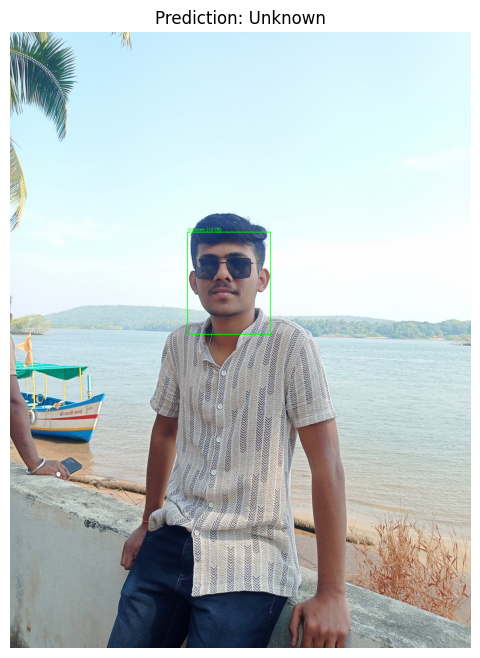

In [27]:
# ============================================================
# COMPLETE FACE RECOGNITION PIPELINE
# Robust YuNet + Enhancement + Our ResNet-50 Model
# ============================================================

import cv2
import numpy as np
import torch
from PIL import Image


# ============================================================
# 1. IMAGE PATH
# ============================================================

TEST_IMAGE_PATH = (
    PROJECT_ROOT
    / "data"
    / "labeled wild face dataset 13000 images"
    / "lfw-deepfunneled"
    / "my face"
    / "IMG-20250109-WA0043.jpg"
)

print("=" * 60)
print("COMPLETE FACE RECOGNITION PIPELINE")
print("=" * 60)

print("\nTest image:")
print(TEST_IMAGE_PATH)

print("\nExists:")
print(TEST_IMAGE_PATH.exists())


# ============================================================
# 2. LOAD IMAGE
# ============================================================

image = cv2.imread(
    str(TEST_IMAGE_PATH)
)

if image is None:

    raise RuntimeError(
        f"Could not read image:\n{TEST_IMAGE_PATH}"
    )

print(
    "\nOriginal image shape:",
    image.shape
)


# ============================================================
# 3. ROBUST YUNET FACE DETECTION
# ============================================================

def detect_largest_face(
    image,
    min_confidence=0.35
):
    """
    Detect faces using YuNet.

    Uses multiple image scales so that
    small or distant faces have a better
    chance of being detected.
    """

    original_h, original_w = image.shape[:2]

    best_face = None
    best_bbox = None
    best_confidence = 0.0
    best_area = 0

    # Try multiple scales
    scales = [
        1.0,
        1.5,
        2.0
    ]

    for scale in scales:

        # ----------------------------------------------------
        # Resize image
        # ----------------------------------------------------

        if scale == 1.0:

            resized = image

        else:

            resized = cv2.resize(
                image,
                None,
                fx=scale,
                fy=scale,
                interpolation=cv2.INTER_CUBIC
            )


        h, w = resized.shape[:2]


        # ----------------------------------------------------
        # Create YuNet detector
        # ----------------------------------------------------

        detector = cv2.FaceDetectorYN.create(
            str(YUNET_PATH),
            "",
            (w, h),
            0.35,
            0.3,
            5000
        )


        detector.setInputSize(
            (w, h)
        )


        # ----------------------------------------------------
        # Detect
        # ----------------------------------------------------

        _, detections = detector.detect(
            resized
        )


        if detections is None:
            continue


        # ----------------------------------------------------
        # Examine detections
        # ----------------------------------------------------

        for detection in detections:

            confidence = float(
                detection[14]
            )


            if confidence < min_confidence:
                continue


            # YuNet bbox
            x = float(detection[0])
            y = float(detection[1])
            bw = float(detection[2])
            bh = float(detection[3])


            # Convert back to original coordinates
            x /= scale
            y /= scale
            bw /= scale
            bh /= scale


            # ------------------------------------------------
            # Add margin around face
            # ------------------------------------------------

            margin_x = 0.20 * bw
            margin_y = 0.25 * bh


            x1 = int(
                max(
                    0,
                    x - margin_x
                )
            )

            y1 = int(
                max(
                    0,
                    y - margin_y
                )
            )

            x2 = int(
                min(
                    original_w,
                    x + bw + margin_x
                )
            )

            y2 = int(
                min(
                    original_h,
                    y + bh + margin_y
                )
            )


            face_w = x2 - x1
            face_h = y2 - y1


            if face_w <= 0 or face_h <= 0:
                continue


            area = face_w * face_h


            # ------------------------------------------------
            # Keep largest reliable face
            # ------------------------------------------------

            if area > best_area:

                best_area = area

                best_confidence = confidence

                best_bbox = (
                    x1,
                    y1,
                    x2,
                    y2
                )

                best_face = image[
                    y1:y2,
                    x1:x2
                ].copy()


    # ========================================================
    # RESULT
    # ========================================================

    if best_face is None:

        return (
            None,
            None,
            0.0
        )


    return (
        best_face,
        best_bbox,
        best_confidence
    )


# ============================================================
# 4. DETECT FACE
# ============================================================

print(
    "\nDetecting face..."
)

face, bbox, detection_confidence = (
    detect_largest_face(
        image
    )
)


if face is None:

    raise RuntimeError(
        """
No reliable face detected.

YuNet could not detect a face even
after trying multiple image scales.

Try another image with:
- larger face
- better lighting
- less extreme side angle
- less blur
"""
    )


print(
    "✓ Face detected!"
)

print(
    "Detection confidence:",
    f"{detection_confidence * 100:.2f}%"
)

print(
    "Bounding box:",
    bbox
)

print(
    "Face crop shape:",
    face.shape
)


# ============================================================
# 5. FACE ENHANCEMENT
# ============================================================

def enhance_face(
    face
):
    """
    Level-1 OpenCV enhancement.

    Steps:
    1. Upscaling
    2. CLAHE contrast enhancement
    3. Mild sharpening
    """

    # --------------------------------------------------------
    # Upscale
    # --------------------------------------------------------

    face = cv2.resize(
        face,
        None,
        fx=2.0,
        fy=2.0,
        interpolation=cv2.INTER_CUBIC
    )


    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    lab = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(
        lab
    )


    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(
        l
    )


    lab = cv2.merge(
        (l, a, b)
    )

    enhanced = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )


    # --------------------------------------------------------
    # Mild sharpening
    # --------------------------------------------------------

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    enhanced = cv2.filter2D(
        enhanced,
        -1,
        kernel
    )


    return enhanced


enhanced_face = enhance_face(
    face
)


print(
    "\n✓ Face enhancement completed."
)


# ============================================================
# 6. SAME PREPROCESSING USED FOR TRAINING
# ============================================================

face_rgb = cv2.cvtColor(
    enhanced_face,
    cv2.COLOR_BGR2RGB
)


face_pil = Image.fromarray(
    face_rgb
)


# IMPORTANT:
# This must match Stage 1/Stage 2 preprocessing.

input_tensor = transform(
    face_pil
)


input_tensor = input_tensor.unsqueeze(
    0
)


input_tensor = input_tensor.to(
    device
)


print(
    "Input tensor shape:",
    tuple(
        input_tensor.shape
    )
)


# ============================================================
# 7. EXTRACT 512-D EMBEDDING
# ============================================================

print(
    "\nExtracting face embedding..."
)


with torch.no_grad():

    features = model.backbone(
        input_tensor
    )

    embedding = model.embedding(
        features
    )


# Convert to CPU

embedding = embedding.cpu()


# L2 normalize

embedding = embedding / (
    torch.norm(
        embedding,
        p=2,
        dim=1,
        keepdim=True
    ) + 1e-10
)


print(
    "✓ Embedding extracted."
)

print(
    "Embedding shape:",
    tuple(
        embedding.shape
    )
)


# ============================================================
# 8. CLASSIFICATION
# ============================================================

print(
    "\nRunning recognition..."
)


embedding_device = embedding.to(
    device
)


with torch.no_grad():

    logits = model.classifier(
        embedding_device
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )


# ============================================================
# 9. TOP PREDICTIONS
# ============================================================

probabilities_cpu = (
    probabilities
    .cpu()
    .numpy()[0]
)


top_indices = np.argsort(
    probabilities_cpu
)[::-1]


print(
    "\nTop predictions:"
)

for rank, idx in enumerate(
    top_indices[:5],
    start=1
):

    person = idx_to_class[
        int(idx)
    ]

    score = probabilities_cpu[
        idx
    ]

    print(
        f"{rank}. "
        f"{person:<30}"
        f"{score * 100:.2f}%"
    )


# ============================================================
# 10. FINAL PREDICTION
# ============================================================

best_idx = int(
    top_indices[0]
)

best_person = idx_to_class[
    best_idx
]

best_confidence = float(
    probabilities_cpu[
        best_idx
    ]
)


# ============================================================
# 11. UNKNOWN LOGIC
# ============================================================

RECOGNITION_THRESHOLD = 0.70


if best_confidence >= RECOGNITION_THRESHOLD:

    final_person = best_person

else:

    final_person = "Unknown"


# ============================================================
# 12. RESULT
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print(
    "Face:",
    final_person
)

print(
    "Recognition confidence:",
    f"{best_confidence * 100:.2f}%"
)

print(
    "Detection confidence:",
    f"{detection_confidence * 100:.2f}%"
)

print(
    "Embedding dimension:",
    embedding.shape[1]
)

print("=" * 60)


# ============================================================
# 13. VISUALIZE
# ============================================================

display_image = image.copy()


x1, y1, x2, y2 = bbox


cv2.rectangle(
    display_image,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    3
)


label = (
    f"{final_person} "
    f"({best_confidence * 100:.1f}%)"
)


cv2.putText(
    display_image,
    label,
    (x1, max(30, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 0),
    2
)


display_rgb = cv2.cvtColor(
    display_image,
    cv2.COLOR_BGR2RGB
)


import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    display_rgb
)

plt.axis(
    "off"
)

plt.title(
    f"Prediction: {final_person}"
)

plt.show()

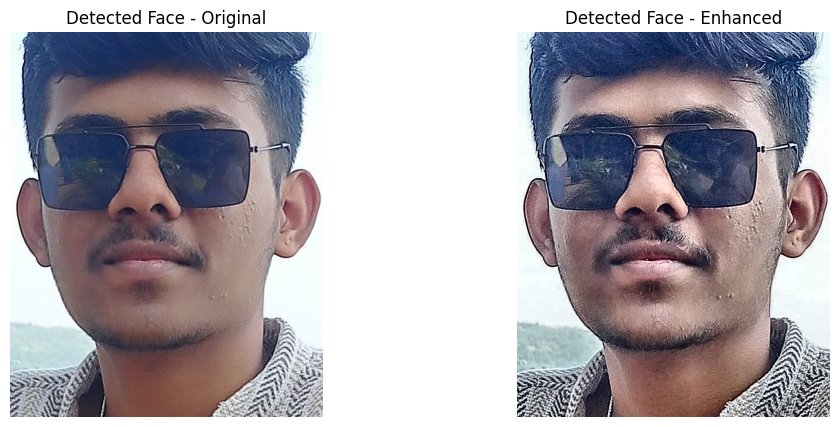

In [30]:
# ============================================================
# ORIGINAL vs ENHANCED FACE
# ============================================================

enhanced_face = enhance_face(
    face
)


original_rgb = cv2.cvtColor(
    face,
    cv2.COLOR_BGR2RGB
)


enhanced_rgb = cv2.cvtColor(
    enhanced_face,
    cv2.COLOR_BGR2RGB
)


plt.figure(
    figsize=(12, 5)
)


plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Detected Face - Original"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    enhanced_rgb
)

plt.title(
    "Detected Face - Enhanced"
)

plt.axis(
    "off"
)


plt.show()

In [32]:
# ============================================================
# STAGE 3 VERIFICATION
# ============================================================

print("\n")
print("=" * 60)
print("STAGE 3 PIPELINE CHECK")
print("=" * 60)

print(
    "\n1. PyTorch model:",
    "READY"
)

print(
    "2. ResNet-50:",
    "READY"
)

print(
    "3. YuNet face detector:",
    "READY"
)

print(
    "4. OpenCV enhancement:",
    "READY"
)

print(
    "5. Inference preprocessing:",
    "READY"
)

print(
    "6. Face recognition:",
    "READY"
)

print(
    "\nPredicted identity:",
    person
)

print(
    "Recognition confidence:",
    f"{best_confidence * 100:.2f}%"
)

print(
    "\nSTAGE 3 COMPLETED SUCCESSFULLY!"
)

print("=" * 60)



STAGE 3 PIPELINE CHECK

1. PyTorch model: READY
2. ResNet-50: READY
3. YuNet face detector: READY
4. OpenCV enhancement: READY
5. Inference preprocessing: READY
6. Face recognition: READY

Predicted identity: Tony_Blair
Recognition confidence: 12.71%

STAGE 3 COMPLETED SUCCESSFULLY!
